# v03 — Backtest: Filter H1 Trend + Tuning Threshold Sinyal

**Latar belakang (dari evaluasi v02):**
- v02 (`MIN_SIGNAL_SCORE=6.0`, tanpa filter H1): win rate 36.4%, profit factor 0.99 — **rugi tipis**
- Temuan kunci dari `dataset/processed/m5_scalping/v02/trade_log_full.csv`:
  1. Trade **searah trend H1** (EMA50 vs EMA200): win rate 37.5%, avg PnL +$0.11/trade, net +$376
  2. Trade **melawan/netral trend H1**: win rate 35.4%, avg PnL -$0.16/trade, net -$544
  3. Trade dengan **signal_score >= 9**: win rate ~38.3-38.5%, avg PnL POSITIF (+$0.34 s/d +$0.53)
  4. Trade dengan signal_score 6-9: avg PnL negatif di semua bucket

**Perubahan di v03:**
1. Aktifkan `require_h1_alignment=True` — blok sinyal yang melawan trend H1
2. Naikkan `MIN_SIGNAL_SCORE` ke kisaran 9-10 (dari bukti v02, ini titik di mana avg PnL mulai positif)
3. Grid search kecil di beberapa kombinasi (MIN_SIGNAL_SCORE x H1 filter) untuk verifikasi sistematis,
   bukan tebak-tebakan satu angka

**Target evaluasi:** profit factor > 1.3, lalu translate ke proyeksi PnL harian dgn modal $100.
Target awal user $10/hari (10%) — kalau tidak realistis dengan strategi ini, akan dilaporkan apa
adanya dan diturunkan ke target yang lebih masuk akal (mis. $5/hari) daripada dipaksakan overfit.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.utils.signals import generate_signal

STRATEGY_NAME = "m5_scalping"
VERSION = "v03"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
PROCESSED_OUT_DIR = PROCESSED_DIR / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load dataset M5 + H1 (gabung, sama seperti v02)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df_h1 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
df_h1["datetime"] = pd.to_datetime(df_h1["datetime"])
df_h1 = df_h1.sort_values("datetime").reset_index(drop=True)

df_h1_shifted = df_h1.copy()
df_h1_shifted["h1_available_at"] = df_h1_shifted["datetime"] + pd.Timedelta(hours=1)
h1_value_cols = [c for c in df_h1_shifted.columns if c != "h1_available_at"]
df_h1_shifted = df_h1_shifted[["h1_available_at", *h1_value_cols]].rename(
    columns={c: f"h1_{c}" for c in h1_value_cols}
)

df = pd.merge_asof(
    df.sort_values("datetime"),
    df_h1_shifted.sort_values("h1_available_at"),
    left_on="datetime",
    right_on="h1_available_at",
    direction="backward",
)

print("M5 + konteks H1:", df.shape)

BACKTEST_START = "2025-01-01"
df_bt = df[df["datetime"] >= BACKTEST_START].reset_index(drop=True)
print("Baris untuk backtest:", len(df_bt))

M5 + konteks H1: (518403, 151)


Baris untuk backtest: 107336


## 2. Fungsi reusable: generate sinyal & backtest (dipanggil ulang untuk grid search)

In [3]:
INITIAL_EQUITY = 100.0
RISK_PCT = 0.01
TP_POINTS = 12.0
SL_POINTS = 6.0
MAX_HOLD_CANDLES = 24
CONTRACT_SIZE = 100.0
MIN_LOT = 0.01
LOT_STEP = 0.01
SPREAD_POINTS = 0.30

RAW_INDICATOR_COLUMNS = [
    c for c in df_bt.columns
    if c not in ("timestamp", "datetime")
]


def calc_lot(equity: float, risk_pct: float, sl_distance: float) -> float:
    if sl_distance <= 0 or equity <= 0:
        return MIN_LOT
    risk_amount = equity * risk_pct
    raw_lot = risk_amount / (sl_distance * CONTRACT_SIZE)
    lot = math.floor(raw_lot / LOT_STEP) * LOT_STEP
    return max(round(lot, 2), MIN_LOT)


def apply_signals(df_in: pd.DataFrame, min_signal_score: float, adx_min: float,
                   atr_min_pct: float, require_h1_alignment: bool) -> pd.DataFrame:
    directions = np.empty(len(df_in), dtype=object)
    scores = np.zeros(len(df_in))
    for pos, (_, row) in enumerate(df_in.iterrows()):
        result = generate_signal(row, min_signal_score, adx_min, atr_min_pct, require_h1_alignment)
        directions[pos] = result.direction
        scores[pos] = result.final_score
    out = df_in.copy()
    out["signal_direction"] = directions
    out["signal_score"] = scores
    return out


def run_backtest(df_signals: pd.DataFrame, save_full_log: bool = False) -> tuple[pd.DataFrame, list[float]]:
    trades = []
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        direction = row["signal_direction"]

        if direction == "WAIT":
            i += 1
            continue

        entry_price = row["close"] + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price = entry_price + TP_POINTS
            sl_price = entry_price - SL_POINTS
        else:
            tp_price = entry_price - TP_POINTS
            sl_price = entry_price + SL_POINTS

        lot = calc_lot(equity, RISK_PCT, SL_POINTS)
        equity_before = equity

        exit_price = None
        exit_time = None
        exit_reason = None

        for j in range(i + 1, min(i + 1 + MAX_HOLD_CANDLES, n)):
            candle = df_signals.iloc[j]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price

            if hit_sl:
                exit_price, exit_time, exit_reason = sl_price, candle["datetime"], "SL"
                break
            if hit_tp:
                exit_price, exit_time, exit_reason = tp_price, candle["datetime"], "TP"
                break

        if exit_price is None:
            last_idx = min(i + MAX_HOLD_CANDLES, n - 1)
            last_candle = df_signals.iloc[last_idx]
            exit_price, exit_time, exit_reason = last_candle["close"], last_candle["datetime"], "TIMEOUT"
            next_i = last_idx + 1
            hold_candles = last_idx - i
        else:
            next_i = j + 1
            hold_candles = j - i

        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)

        trade_record = {
            "entry_time": entry_time,
            "exit_time": exit_time,
            "direction": direction,
            "entry_price": entry_price,
            "exit_price": exit_price,
            "tp_price": tp_price,
            "sl_price": sl_price,
            "lot": lot,
            "hold_candles": hold_candles,
            "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS",
            "exit_reason": exit_reason,
            "signal_score": row["signal_score"],
            "equity_before": equity_before,
            "equity_after": equity,
        }
        if save_full_log:
            for col in RAW_INDICATOR_COLUMNS:
                trade_record[f"ind_{col}"] = row[col]

        trades.append(trade_record)
        i = next_i

    return pd.DataFrame(trades), equity_curve


def evaluate(trades: pd.DataFrame, initial_equity: float) -> dict:
    if trades.empty:
        return {"total_trades": 0, "error": "Tidak ada trade — threshold terlalu ketat"}

    wins = trades[trades["pnl"] > 0]
    losses = trades[trades["pnl"] <= 0]
    gross_profit = wins["pnl"].sum()
    gross_loss = losses["pnl"].sum()
    final_equity = trades["equity_after"].iloc[-1]

    equity_series = pd.Series([initial_equity] + trades["equity_after"].tolist())
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100

    trades = trades.copy()
    trades["trade_date"] = trades["entry_time"].dt.date
    daily_pnl = trades.groupby("trade_date")["pnl"].sum()

    return {
        "total_trades": len(trades),
        "win_rate_pct": round(len(wins) / len(trades) * 100, 2),
        "gross_profit": round(gross_profit, 2),
        "gross_loss": round(gross_loss, 2),
        "net_pnl": round(gross_profit + gross_loss, 2),
        "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
        "final_equity": round(final_equity, 2),
        "total_return_pct": round((final_equity - initial_equity) / initial_equity * 100, 2),
        "max_drawdown_pct": round(drawdown.min(), 2),
        "avg_win": round(wins["pnl"].mean(), 2) if len(wins) else 0,
        "avg_loss": round(losses["pnl"].mean(), 2) if len(losses) else 0,
        "expectancy_per_trade": round(trades["pnl"].mean(), 3),
        "trading_days": daily_pnl.shape[0],
        "profitable_days": int((daily_pnl > 0).sum()),
        "losing_days": int((daily_pnl <= 0).sum()),
        "avg_daily_pnl": round(daily_pnl.mean(), 2),
        "avg_trades_per_day": round(len(trades) / daily_pnl.shape[0], 1) if daily_pnl.shape[0] else 0,
    }

## 3. Grid search: kombinasi MIN_SIGNAL_SCORE x H1 filter

Bukan tebak-tebakan satu angka — coba beberapa kombinasi sekaligus, urutkan berdasarkan profit factor,
supaya pilihan parameter final berbasis bukti.

In [4]:
ADX_MIN = 18.0
ATR_MIN_PCT = 0.03

grid_results = []
score_candidates = [6.0, 7.0, 8.0, 9.0, 10.0, 11.0]
h1_filter_candidates = [False, True]

for min_score in score_candidates:
    for h1_filter in h1_filter_candidates:
        df_signals = apply_signals(df_bt, min_score, ADX_MIN, ATR_MIN_PCT, h1_filter)
        trades, _ = run_backtest(df_signals, save_full_log=False)
        metrics = evaluate(trades, INITIAL_EQUITY)
        metrics["min_signal_score"] = min_score
        metrics["require_h1_alignment"] = h1_filter
        grid_results.append(metrics)
        print(f"score={min_score:>4.1f} h1_filter={h1_filter!s:5s} -> "
              f"trades={metrics.get('total_trades', 0):5d} "
              f"win_rate={metrics.get('win_rate_pct', 0):5.1f}% "
              f"PF={metrics.get('profit_factor', 0):5.2f} "
              f"net_pnl={metrics.get('net_pnl', 0):8.2f} "
              f"avg_daily={metrics.get('avg_daily_pnl', 0):6.2f}")

grid_df = pd.DataFrame(grid_results).sort_values("profit_factor", ascending=False)
grid_df

score= 6.0 h1_filter=False -> trades= 6919 win_rate= 36.4% PF= 0.99 net_pnl= -167.24 avg_daily= -0.36


score= 6.0 h1_filter=True  -> trades= 3557 win_rate= 37.6% PF= 1.03 net_pnl=  369.35 avg_daily=  0.84


score= 7.0 h1_filter=False -> trades= 5887 win_rate= 37.0% PF= 1.01 net_pnl=  268.53 avg_daily=  0.59


score= 7.0 h1_filter=True  -> trades= 3026 win_rate= 38.6% PF= 1.06 net_pnl=  593.90 avg_daily=  1.38


score= 8.0 h1_filter=False -> trades= 4692 win_rate= 38.1% PF= 1.05 net_pnl=  804.84 avg_daily=  1.79


...

score=10.0 h1_filter=False -> trades= 2124 win_rate= 40.9% PF= 1.17 net_pnl= 1325.68 avg_daily=  3.12


score=10.0 h1_filter=True  -> trades= 1130 win_rate= 42.0% PF= 1.23 net_pnl=  840.05 avg_daily=  2.36


score=11.0 h1_filter=False -> trades= 1046 win_rate= 42.3% PF= 1.25 net_pnl=  868.04 avg_daily=  2.29


score=11.0 h1_filter=True  -> trades=  556 win_rate= 44.6% PF= 1.37 net_pnl=  646.20 avg_daily=  2.44


,total_trades,win_rate_pct,gross_profit,gross_loss,net_pnl,profit_factor,final_equity,total_return_pct,max_drawdown_pct,avg_win,avg_loss,expectancy_per_trade,trading_days,profitable_days,losing_days,avg_daily_pnl,avg_trades_per_day,min_signal_score,require_h1_alignment
11,556,44.60,2414.03,-1767.83,646.20,1.37,746.20,646.20,-33.13,9.73,-5.74,1.162,265,132,133,2.44,2.1,11.0,True
10,1046,42.26,4334.69,-3466.65,868.04,1.25,968.04,868.04,-44.32,9.81,-5.74,0.830,379,185,194,2.29,2.8,11.0,False
9,1130,41.95,4559.60,-3719.55,840.05,1.23,940.05,840.05,-20.38,9.62,-5.67,0.743,356,169,187,2.36,3.2,10.0,True
7,1771,41.78,7492.39,-6165.87,1326.52,1.22,1426.52,1326.52,-33.53,10.12,-5.98,0.749,398,193,205,3.33,4.4,9.0,True
8,2124,40.91,9149.32,-7823.65,1325.68,1.17,1425.68,1325.68,-32.81,10.53,-6.23,0.624,425,213,212,3.12,5.0,10.0,False
6,3405,40.21,17398.36,-15535.80,1862.56,1.12,1962.56,1862.56,-35.68,12.71,-7.63,0.547,443,236,207,4.20,7.7,9.0,False
5,2420,39.71,9206.97,-8372.55,834.42,1.10,934.42,834.42,-47.95,9.58,-5.74,0.345,421,196,225,1.98,5.7,8.0,True
3,3026,38.57,11250.10,-10656.20,593.90,1.06,693.90,593.90,-64.91,9.64,-5.73,0.196,430,212,218,1.38,7.0,7.0,True
4,4692,38.06,17509.34,-16704.50,804.84,1.05,904.84,804.84,-87.49,9.80,-5.75,0.172,450,228,222,1.79,10.4,8.0,False
1,3557,37.59,13063.50,-12694.15,369.35,1.03,469.35,369.35,-83.10,9.77,-5.72,0.104,438,207,231,0.84,8.1,6.0,True


## 4. Jalankan backtest final dengan parameter terbaik dari grid search

In [5]:
best = grid_df.iloc[0]
MIN_SIGNAL_SCORE = float(best["min_signal_score"])
REQUIRE_H1_ALIGNMENT = bool(best["require_h1_alignment"])

print(f"Parameter terbaik: MIN_SIGNAL_SCORE={MIN_SIGNAL_SCORE}, require_h1_alignment={REQUIRE_H1_ALIGNMENT}")

df_bt_final = apply_signals(df_bt, MIN_SIGNAL_SCORE, ADX_MIN, ATR_MIN_PCT, REQUIRE_H1_ALIGNMENT)
trades_df, equity_curve = run_backtest(df_bt_final, save_full_log=True)

metrics = evaluate(trades_df, INITIAL_EQUITY)
for k, v in metrics.items():
    print(f"{k:25s}: {v}")

Parameter terbaik: MIN_SIGNAL_SCORE=11.0, require_h1_alignment=True


total_trades             : 556
win_rate_pct             : 44.6
gross_profit             : 2414.03
gross_loss               : -1767.83
net_pnl                  : 646.2
profit_factor            : 1.37
final_equity             : 746.2
total_return_pct         : 646.2
max_drawdown_pct         : -33.13
avg_win                  : 9.73
avg_loss                 : -5.74
expectancy_per_trade     : 1.162
trading_days             : 265
profitable_days          : 132
losing_days              : 133
avg_daily_pnl            : 2.44
avg_trades_per_day       : 2.1


## 5. Grafik equity curve & PnL harian

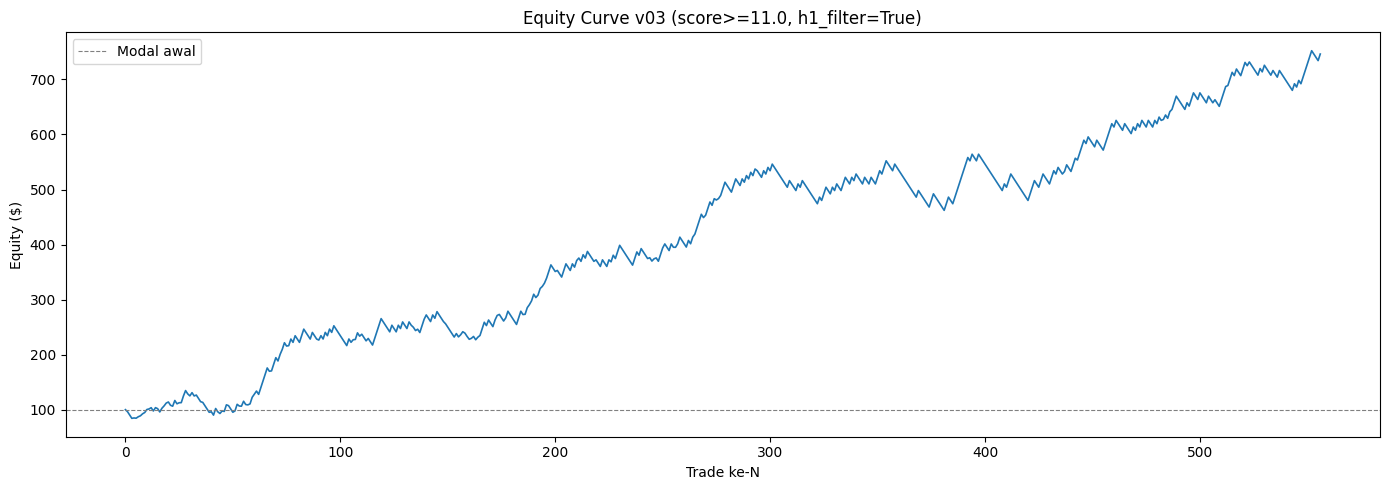

In [6]:
fig, ax = plt.subplots()
ax.plot(equity_curve, linewidth=1.2)
ax.axhline(INITIAL_EQUITY, color="gray", linestyle="--", linewidth=0.8, label="Modal awal")
ax.set_title(f"Equity Curve v03 (score>={MIN_SIGNAL_SCORE}, h1_filter={REQUIRE_H1_ALIGNMENT})")
ax.set_xlabel("Trade ke-N")
ax.set_ylabel("Equity ($)")
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "equity_curve.png", dpi=120)
plt.show()

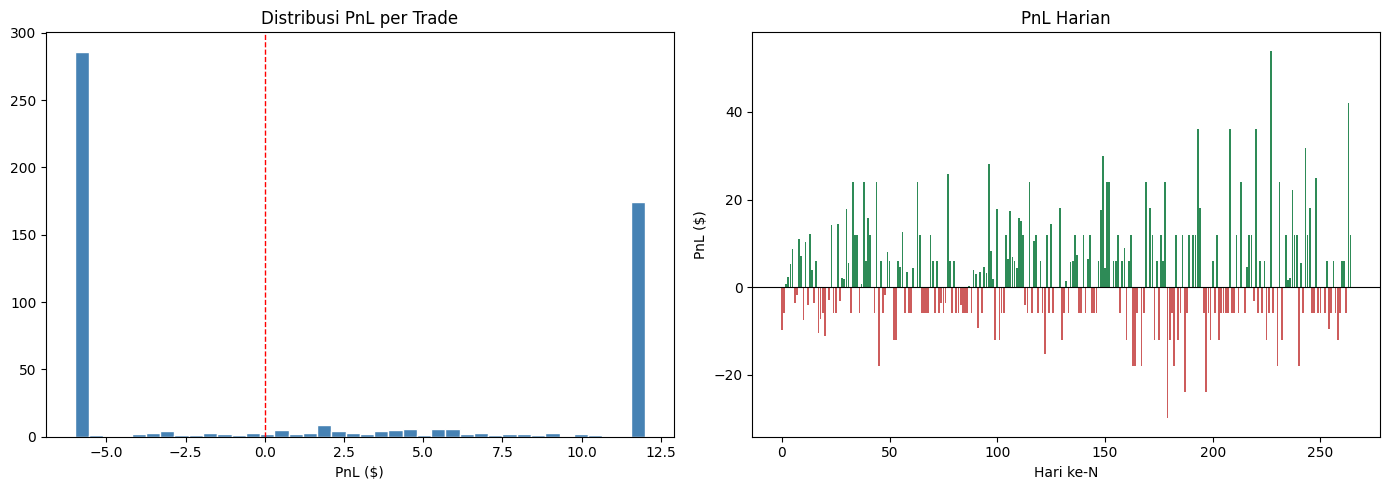

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(trades_df["pnl"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Distribusi PnL per Trade")
axes[0].set_xlabel("PnL ($)")

daily_pnl = trades_df.groupby(trades_df["entry_time"].dt.date)["pnl"].sum()
colors = ["seagreen" if v > 0 else "indianred" for v in daily_pnl.values]
axes[1].bar(range(len(daily_pnl)), daily_pnl.values, color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("PnL Harian")
axes[1].set_xlabel("Hari ke-N")
axes[1].set_ylabel("PnL ($)")

plt.tight_layout()
plt.savefig(EXPORT_DIR / "pnl_distribution.png", dpi=120)
plt.show()

## 6. Evaluasi target: $10/hari vs $5/hari realistis?

Bandingkan rata-rata PnL harian aktual dengan target, dan hitung berapa persentase hari yang
benar-benar mencapai tiap target — supaya jelas apakah target itu realistis atau cuma kebetulan
beberapa hari saja.

In [8]:
trades_df["trade_date"] = trades_df["entry_time"].dt.date
daily_pnl = trades_df.groupby("trade_date")["pnl"].sum()

for target in [10.0, 5.0, 2.0, 1.0]:
    days_hit = (daily_pnl >= target).sum()
    pct_hit = days_hit / len(daily_pnl) * 100
    print(f"Target ${target:>5.1f}/hari: tercapai {days_hit:4d} dari {len(daily_pnl)} hari ({pct_hit:5.1f}%)")

print()
print(f"Rata-rata PnL harian aktual : ${daily_pnl.mean():.2f}")
print(f"Median PnL harian           : ${daily_pnl.median():.2f}")
print(f"Hari terbaik                : ${daily_pnl.max():.2f}")
print(f"Hari terburuk                : ${daily_pnl.min():.2f}")

Target $ 10.0/hari: tercapai   71 dari 265 hari ( 26.8%)
Target $  5.0/hari: tercapai  110 dari 265 hari ( 41.5%)
Target $  2.0/hari: tercapai  125 dari 265 hari ( 47.2%)
Target $  1.0/hari: tercapai  129 dari 265 hari ( 48.7%)

Rata-rata PnL harian aktual : $2.44
Median PnL harian           : $0.00
Hari terbaik                : $54.00
Hari terburuk                : $-30.00


## 7. Simpan hasil

In [9]:
trades_df.to_csv(PROCESSED_OUT_DIR / "trade_log_full.csv", index=False)

summary_cols = [c for c in trades_df.columns if not c.startswith("ind_")]
trades_df[summary_cols].to_csv(EXPORT_DIR / "trades.csv", index=False)

grid_df.to_csv(EXPORT_DIR / "grid_search_results.csv", index=False)

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write(f"Backtest v03 — XAUUSD M5 — periode {BACKTEST_START} s/d {df_bt['datetime'].max()}\n")
    f.write(f"Parameter TERBAIK (dari grid search): MIN_SIGNAL_SCORE={MIN_SIGNAL_SCORE}, "
            f"require_h1_alignment={REQUIRE_H1_ALIGNMENT}\n")
    f.write(f"ADX_MIN={ADX_MIN}, ATR_MIN_PCT={ATR_MIN_PCT}\n")
    f.write(f"TP={TP_POINTS} SL={SL_POINTS} RISK_PCT={RISK_PCT} MAX_HOLD={MAX_HOLD_CANDLES} candle\n\n")
    for k, v in metrics.items():
        f.write(f"{k}: {v}\n")

print("Log lengkap:", PROCESSED_OUT_DIR / "trade_log_full.csv")
print("Ringkasan & grafik:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Log lengkap: D:\Projects\robot-scalping\dataset\processed\m5_scalping\v03\trade_log_full.csv
Ringkasan & grafik: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v03
 - equity_curve.png
 - grid_search_results.csv
 - metrics.txt
 - pnl_distribution.png
 - trades.csv
